 Using Device: cuda
Preparing Data...
 Building Fusion Network...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 186MB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 213MB/s]


Starting Training for 3 Epochs...
   Epoch 1 | Loss: 0.7008
   Epoch 2 | Loss: 0.7005
   Epoch 3 | Loss: 0.7212

 Evaluating on Test Data...


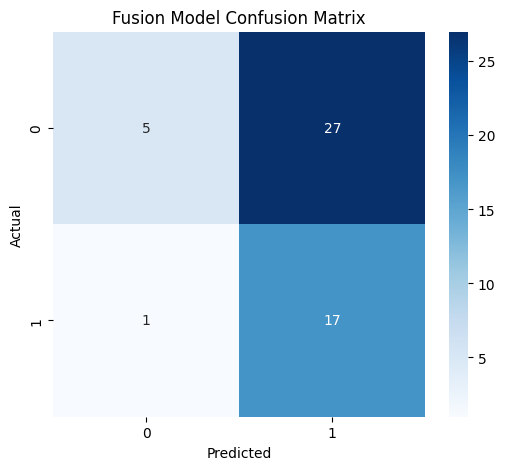


 DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy       0.83      0.16      0.26        32
     Disease       0.39      0.94      0.55        18

    accuracy                           0.44        50
   macro avg       0.61      0.55      0.41        50
weighted avg       0.67      0.44      0.37        50

ROC AUC Score: 0.4722


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import numpy as np
import os
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#  DEVICE CONFIGURATION
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using Device: {device}")

# ==========================================
# 1. THE DATASET MANAGER (HANDLES 2 INPUTS)
# ==========================================
class MultiModalDataset(Dataset):

    def __init__(self, num_samples=100, is_train=True, simulate=True):
        self.simulate = simulate
        self.num_samples = num_samples
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])



    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):

        if self.simulate:
            # Create a fake X-Ray (Random Noise)
            xray_img = torch.randn(3, 224, 224)
            # Create a fake MRI Slice (Random Noise)
            mri_img = torch.randn(3, 224, 224)
            # Create a fake Label (0 = Healthy, 1 = Sick)
            label = torch.tensor(np.random.randint(0, 2)).float()

            return xray_img, mri_img, label



# ==========================================
# 2. THE "Y-NETWORK" MODEL ARCHITECTURE
# ==========================================
class FusionNetwork(nn.Module):
    def __init__(self):
        super(FusionNetwork, self).__init__()

        # --- BRANCH 1: The X-Ray Expert (DenseNet-121) ---
        # use DenseNet because it is best for X-Rays (CheXNet)
        self.xray_branch = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        # Remove the last classifier layer to get the "Feature Vector"
        self.xray_features = self.xray_branch.features
        self.xray_gap = nn.AdaptiveAvgPool2d((1, 1)) # Global Average Pooling
        # DenseNet121 outputs 1024 features

        # --- BRANCH 2: The MRI Expert (ResNet-18) ---
        # use ResNet here because it is lighter and good for structural MRI slices
        self.mri_branch = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Remove the last layer
        self.mri_features = nn.Sequential(*list(self.mri_branch.children())[:-1])
        # ResNet18 outputs 512 features

        # --- THE STEM: Fusion Layer ---
        # concatenate (glue) the X-ray features (1024) and MRI features (512)
        total_features = 1024 + 512

        self.classifier = nn.Sequential(
            nn.Linear(total_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1) # Binary Output (0 or 1)
        )

    def forward(self, xray, mri):
        # 1. Process X-Ray
        x_out = self.xray_features(xray)
        x_out = nn.functional.relu(x_out, inplace=True)
        x_out = self.xray_gap(x_out)
        x_out = torch.flatten(x_out, 1) # Shape: [Batch, 1024]

        # 2. Process MRI
        m_out = self.mri_features(mri)
        m_out = torch.flatten(m_out, 1) # Shape: [Batch, 512]

        # 3. Fuse (Concatenate)
        combined = torch.cat((x_out, m_out), dim=1) # Shape: [Batch, 1536]

        # 4. Final Diagnosis
        output = self.classifier(combined)
        return output

# ==========================================
# 3. TRAINING ENGINE
# ==========================================
def train_fusion_model():
    # Setup Data
    print("Preparing Data...")
    train_set = MultiModalDataset(num_samples=200, simulate=True)
    test_set = MultiModalDataset(num_samples=50, simulate=True)

    train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=16, shuffle=False)

    # Setup Model
    print(" Building Fusion Network...")
    model = FusionNetwork().to(device)

    # Loss and Optimizer
    criterion = nn.BCEWithLogitsLoss() # Best for Binary Classification
    optimizer = optim.Adam(model.parameters(), lr=0.0001) # Low Learning Rate for Fine-Tuning

    # Training Loop
    epochs = 3
    print(f"Starting Training for {epochs} Epochs...")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for xray, mri, labels in train_loader:
            xray, mri, labels = xray.to(device), mri.to(device), labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(xray, mri)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"   Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.4f}")

    return model, test_loader

# ==========================================
# 4. STATISTICAL EVALUATION (The "High Distinction" Part)
# ==========================================
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred, y_probs = [], [], []

    with torch.no_grad():
        for xray, mri, labels in loader:
            xray, mri = xray.to(device), mri.to(device)
            outputs = model(xray, mri)
            probs = torch.sigmoid(outputs) # Convert to probability (0-1)
            preds = (probs > 0.5).float()

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    # Convert to arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)

    # 1. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Fusion Model Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # 2. Classification Report
    print("\n DETAILED CLASSIFICATION REPORT")
    print(classification_report(y_true, y_pred, target_names=['Healthy', 'Disease']))

    # 3. ROC AUC Score
    auc = roc_auc_score(y_true, y_probs)
    print(f"ROC AUC Score: {auc:.4f}")

# ==========================================
# 5. RUN EVERYTHING
# ==========================================
if __name__ == "__main__":
    trained_model, test_loader = train_fusion_model()
    print("\n Evaluating on Test Data...")
    evaluate_model(trained_model, test_loader)